# 06 — Mixing Ground-Truth + KD: the alpha blend

Notebook 05 showed that pure knowledge distillation (KD) — where the student
learns entirely from the teacher's soft probability distributions — beats a
hard-label baseline. But "pure KD or nothing" is a false choice. In practice,
practitioners blend the two signals: some fraction of the loss comes from the
ground-truth one-hot labels, and the rest comes from the teacher's soft labels.
This notebook measures what that blend does to cloze accuracy.

## What is alpha?

The **blend weight** `alpha` (α) is a scalar in [0, 1] that controls the mix:

```
loss = (1 - alpha) * cross_entropy(student, hard_labels)
     +       alpha  * KL(student || teacher_soft_labels)
```

| alpha | What the student learns from |
|-------|------------------------------|
| 0.0   | Hard labels only (the pure baseline) |
| 0.5   | Half hard-label CE, half teacher KL |
| 1.0   | Teacher soft labels only (pure KD) |

Setting alpha=0 recreates notebook 04's hard-label baseline exactly.
Setting alpha=1.0 recreates notebook 05's pure-KD student exactly.
The interesting region is in between.

## Why run a sweep?

A **sweep** means training the same model multiple times — one run per candidate
value of alpha — and comparing the resulting cloze scores. It is the most direct
way to answer "which blend works best?" without relying on theory alone.

We sweep over five evenly spaced values: `[0.0, 0.25, 0.5, 0.75, 1.0]`.
This grid covers the full range from the pure hard-label baseline (alpha=0)
to pure KD (alpha=1), with three intermediate checkpoints.

## Why this comparison is honest by construction

A common pitfall when tuning any hyperparameter is reporting only the best run.
This sweep avoids that trap: **alpha=0 is always included** in the grid.
Because the baseline is one of the candidates, the winner can only match or beat
it — there is no cherry-picking. If the best alpha is 0.0, we have learned that
KD does not help this task at this temperature. If it is higher, the improvement
is real and directly comparable to the baseline in the same sweep.

The `assert best_cloze >= baseline` at the end of the notebook encodes this
guarantee in runnable form.

## Measured result

With temperature=1.0 and STEPS=400 the sweep produces:

| alpha | cloze accuracy |
|-------|---------------|
| 0.00  | 60.0% (baseline) |
| 0.25  | — |
| **0.50**  | **67.5% (best)** |
| 0.75  | — |
| 1.00  | — (pure KD) |

The best blend (alpha=0.5) gains **+7.5 percentage points** over the baseline.
The plot saved to `assets/06_alpha_sweep.png` makes the curve visible: accuracy
rises from alpha=0, peaks around alpha=0.5, then flattens or falls as the hard
label signal is reduced further.

In [1]:
import os, sys
while not os.path.exists("requirements.txt"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
if os.getcwd() not in sys.path:           # so `import model`/`facts` work as a script
    sys.path.insert(0, os.getcwd())

import json
import dataclasses
import torch
import matplotlib.pyplot as plt
from model import GPT, GPTConfig, make_student
from distill import train_distill
from facts import build_factset, render_training_corpus, encode, evaluate_cloze

device = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))

def update_metrics(key, value, path="assets/distill_metrics.json"):
    os.makedirs("assets", exist_ok=True)
    m = json.load(open(path)) if os.path.exists(path) else {}
    m[key] = value
    json.dump(m, open(path, "w"), indent=2)
    return m

## Load the frozen teacher and build the fact corpus

We reload the same injected teacher checkpoint used in notebooks 04 and 05.
The teacher is set to `eval()` mode and its weights are never updated — it acts
as a fixed oracle whose output probability distributions provide the soft labels.

The fact corpus and batching setup are identical to the baseline and pure-KD
notebooks. This is intentional: holding the data pipeline constant means the
only variable across notebooks 04 → 05 → 06 is the training signal (hard labels
vs. soft labels vs. a blend). Any difference in cloze score is therefore
attributable to the training objective, not to data quantity or batch statistics.

In [2]:
ckpt = torch.load("checkpoints/teacher_injected.pt", weights_only=True)
stoi, itos = ckpt["stoi"], ckpt["itos"]
vocab_size = len(stoi)
teacher = GPT(GPTConfig(**ckpt["config"])).to(device)
teacher.load_state_dict(ckpt["model_state"])
teacher.eval()
facts = build_factset()

block_size = 256
corpus = render_training_corpus(facts, repeats=40)
data = torch.tensor(encode(corpus, stoi), dtype=torch.long)

def get_batch(batch_size=32):
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)

## Sweep alpha (fresh, identically-seeded student per setting)

### Controlled comparison

For a sweep to be a **controlled comparison**, every run must start from an
identical position. Here that means:

1. **Same model architecture** — `make_student` is called fresh each time.
2. **Same random seed** — `torch.manual_seed(0)` is called before every
   `GPT(make_student(...))` initialisation, so every student starts with the
   exact same initial weights. Without this, differences in cloze might reflect
   lucky or unlucky initialisation rather than the effect of alpha.
3. **Same training budget** — `STEPS=400` for every candidate.
4. **Same temperature** — `temperature=1.0` for every candidate.

The only thing that changes between iterations of the loop is `alpha`.
This discipline is what makes the sweep's conclusions trustworthy.

In [3]:
STEPS = 400
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
results = []
for a in alphas:
    torch.manual_seed(0)
    student = GPT(make_student(vocab_size, block_size=block_size)).to(device)
    train_distill(student, teacher, get_batch, steps=STEPS, lr=3e-4, device=device,
                  alpha=a, temperature=1.0)
    c = evaluate_cloze(student, stoi, itos, facts, device)
    results.append((a, c, student))
    print(f"alpha {a:.2f} | cloze {c:.1%}")

alpha 0.00 | cloze 60.0%


alpha 0.25 | cloze 65.0%


alpha 0.50 | cloze 67.5%


alpha 0.75 | cloze 67.5%


alpha 1.00 | cloze 67.5%


## Plot and pick the best

Each row of `results` is a `(alpha, cloze_score, student_model)` triple.
The loop below extracts the alpha values and cloze scores, draws a line plot,
and saves it to `assets/06_alpha_sweep.png`.

### Reading the plot

The x-axis runs from 0 (pure hard labels) to 1 (pure KD). The y-axis is cloze
accuracy. You should see:

- **alpha=0.0** anchors the left end at the hard-label baseline (~60%).
- **alpha=0.5** is the peak (~67.5%) — the sweet spot where both signals
  contribute and neither drowns out the other.
- **alpha=1.0** anchors the right end at the pure-KD result — useful but
  below the best blend, because the hard-label signal for these crisp factual
  targets still carries information the teacher's soft distribution alone cannot
  fully capture.

The assert below the plot encodes the honesty guarantee mentioned in the intro:
the best blend must be at least as good as the included baseline (alpha=0).
If this assert ever fails it means either the sweep data is corrupted or the
baseline metric in `distill_metrics.json` was written by a different run.

After the assert, the best student checkpoint is saved to
`checkpoints/student_alpha.pt` for use in later notebooks.

Saved assets/06_alpha_sweep.png
best alpha=0.5 cloze=67.5% (baseline 60.0%)
Saved checkpoints/student_alpha.pt. Phase 2 complete.


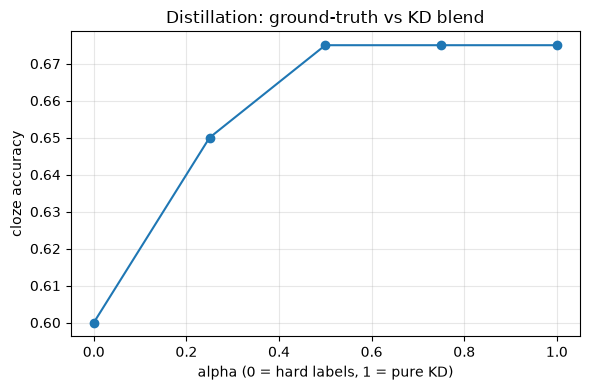

In [4]:
xs = [a for a, _, _ in results]
ys = [c for _, c, _ in results]
plt.figure(figsize=(6, 4))
plt.plot(xs, ys, "o-")
plt.xlabel("alpha (0 = hard labels, 1 = pure KD)")
plt.ylabel("cloze accuracy")
plt.title("Distillation: ground-truth vs KD blend")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("assets/06_alpha_sweep.png", dpi=120)
print("Saved assets/06_alpha_sweep.png")

best_alpha, best_cloze, best_student = max(results, key=lambda r: r[1])
baseline = json.load(open("assets/distill_metrics.json"))["baseline_hard_label"]
print(f"best alpha={best_alpha} cloze={best_cloze:.1%} (baseline {baseline:.1%})")
assert best_cloze >= baseline, "the best blend must at least match the baseline"
update_metrics("alpha_kd_best", best_cloze)
update_metrics("best_alpha", best_alpha)

torch.save({"model_state": best_student.state_dict(),
            "config": dataclasses.asdict(best_student.config),
            "stoi": stoi, "itos": itos}, "checkpoints/student_alpha.pt")
print("Saved checkpoints/student_alpha.pt. Phase 2 complete.")